In [735]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

url = "http://127.0.0.1:5000"

# Data Loading

In [736]:
response = requests.get(f"{url}/stock/ml/BUMI")
json = response.json()
data = json.get('data')
df = pd.DataFrame(data)
df = df.drop(['attention_mask', 'content', 'content_abbreviation', 'content_clean', 'content_entity', 'content_stemmed', 'content_stopword_removed', 'emb_mean', 'embedding', 'sentiment_label', 'full_text', 'input_ids', 'negative_grouped_news_sentiment', 'positive_grouped_news_sentiment', 'title', 'title_abbreviation', 'title_clean', 'title_entity', 'title_stemmed', 'title_stopword_removed'], axis=1)
df["sentiment_score"] = df["sentiment_score"].apply(
    lambda x: [] if pd.isna(x) else ast.literal_eval(x)
)
df["foreign_net"] = df["foreign_buy"] - df["foreign_sell"]
df["Volume"] = np.log1p(df["Volume"])
df["value"] = np.log1p(df["value"])
df["foreign_buy"] = np.log1p(df["foreign_buy"])
df["foreign_sell"] = np.log1p(df["foreign_sell"])
df["bid_volume"] = np.log1p(df["bid_volume"])
df["offer_volume"] = np.log1p(df["offer_volume"])
df

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,date,ema100,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,2020-01-02,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,2020-01-03,66.138614,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,2020-01-06,66.195275,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,2020-01-07,66.250814,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,2020-01-08,66.285451,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,147.0,6037.841797,148.0,139.0,142.0,21.386982,147.0,18.090258,2026-07-13,194.060024,...,169.62,80.338110,77.213786,170.558606,26.351984,226.338416,140.252381,92.800000,178.606275,266024800.0
1572,149.0,6039.520996,155.0,146.0,148.0,21.963438,148.0,18.205629,2026-07-14,193.167746,...,167.80,54.644945,9.507265,168.805257,26.977335,225.675644,137.933333,93.200000,175.846275,-144472200.0
1573,148.0,6041.972168,152.0,147.0,150.0,20.994785,147.0,17.889761,2026-07-15,192.273335,...,166.16,37.309350,25.207001,167.518626,26.002531,224.836436,135.976190,95.533333,173.407059,-287818500.0
1574,149.0,6108.208984,152.0,147.0,148.0,21.166431,149.0,16.941977,2026-07-16,191.416437,...,164.54,11.571422,0.000000,165.823727,26.173223,223.502178,133.638095,97.000000,170.903529,-335497100.0


In [737]:
df = df.dropna()

In [738]:
df.columns

Index(['Close', 'Close_ihsg', 'High', 'Low', 'Open', 'Volume', 'bid_value',
       'bid_volume', 'date', 'ema100', 'ema20', 'ema5', 'ema50', 'foreign_buy',
       'foreign_sell', 'lb_bolinger', 'macd_hist', 'macd_line', 'macd_signal',
       'mb_bolinger', 'mean_sentiment_score_negative',
       'mean_sentiment_score_positive', 'offer_value', 'offer_volume',
       'percent_bolinger', 'psar', 'return', 'return_num', 'rsi',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_10',
       'sentiment_pca_11', 'sentiment_pca_12', 'sentiment_pca_13',
       'sentiment_pca_14', 'sentiment_pca_15', 'sentiment_pca_16',
       'sentiment_pca_17', 'sentiment_pca_18', 'sentiment_pca_19',
       'sentiment_pca_2', 'sentiment_pca_20', 'sentiment_pca_21',
       'sentiment_pca_22', 'sentiment_pca_23', 'sentiment_pca_24',
       'sentiment_pca_25', 'sentiment_pca_26', 'sentiment_pca_27',
       'sentiment_pca_28', 'sentiment_pca_29', 'sentiment_pca_3',
       'sentiment_pca_30', 'sentiment_pca

In [739]:
df.describe()

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
count,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,...,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1.576000e+03
mean,110.270305,6698.155363,113.933376,107.547589,110.696066,19.847022,101.276015,14.728050,106.356905,109.779043,...,106.982487,49.342611,49.600333,130.660478,24.380851,99.314341,98.464431,73.295389,102.261940,-5.072121e+07
std,63.542506,943.859524,66.532341,61.095254,63.989847,2.329940,71.686703,6.132760,52.230905,61.370935,...,62.207030,36.462863,39.172492,89.990666,2.888255,59.418264,57.456183,42.380200,60.547052,3.662403e+08
min,50.000000,0.000000,50.000000,50.000000,50.000000,0.000000,0.000000,0.000000,50.377633,50.000012,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.587476e+09
25%,62.000000,6158.311401,64.000000,60.000000,62.000000,19.174770,60.000000,15.179781,64.229015,62.504253,...,61.895000,12.242466,0.000000,70.144686,23.491520,60.294406,55.722619,41.133333,59.096667,-6.449900e+07
50%,96.000000,6856.133545,100.000000,93.500000,96.000000,20.106730,93.000000,17.047747,98.964263,94.067463,...,92.040000,51.838912,54.374232,114.952922,24.736585,88.118614,84.650000,63.333333,87.819608,-1.912250e+06
75%,136.250000,7187.029175,141.000000,133.000000,137.000000,21.182397,135.000000,17.986823,127.334188,135.604665,...,132.725000,85.438871,89.275813,153.934904,25.903124,124.695446,122.857143,90.750000,127.061569,2.192355e+07
max,464.000000,9134.700195,484.000000,456.000000,470.000000,24.076693,464.000000,21.654616,266.331516,398.143060,...,338.960000,100.000000,100.000000,560.491098,29.681847,312.672871,385.285714,307.466667,351.366275,2.762691e+09


# Data Preprocessing

# Addons Data

## RSI

Indikator ini merupakan indikator momentum yang dapat menjadi tolak ukur investor menentukan titik beli dan titik jual suatu saham [5]. Indikator ini di normalisasi dari skala 1 – 100 dengan area dibawah 30 merupakan area jenuh jual (oversold) dan area diatas 70 adalah area jenuh beli (overbought) [6]. Persamaan yang digunakan dalam menghitung RSI suatu periode saham adalah 

$$ RSI = 100 - \frac{100}{1 + RS} $$
$$ RS = \frac{SMA(U)}{SMA(D)}$$

RSI: Relative Strength Index

RS: Relative Strength

SMA(U): Simple Moving Average Up (Jika harga naik, U = Change, D = 0)

SMA(D): Simple Moving Average Down (Jika harga turun, U = 0, D = Change). Jika harga tetap, U = 0, D = 0.

Indikator ini kemudian dikembangkan dengan membandingkan harga saat ini dengan rata-rata nya yang disebut dengan Stochastik RSI (Stoch). 

$$Stoch(K\%) = \frac{(RSI - min(RSI))}{(max(RSI) - min(RSI))} \times 100 $$
$$D\% = SMA(K\%)$$

Dengan:

$K\%$ = Normalisasi RSI ke skala 0-1 dikali 100

$D\%$ = Rata - rata K% selama 3 hari

## MACD (Moving Average Convergence/Divergence)

merupakan indikator trend (Trend Indicator) yang menampilkan perbedaan antara pergerakan harga exponential rata-rata (Exponential  Moving Average (EMA)) yang lebih cepat atau lebih lambat dari harga penutupan (Close Price) [5]. Indikator ini dirancang untuk mengidentifikasi perubahan yang terjadi pada trend, namun tidak direkomendasikan untuk digunakan untuk pasar dengan kondisi yang volatile. Terdapat 3 signal yang diberikan dari indikator MACD ini, yaitu [5]:

1.	MACD menyilang dengan garis sinyal (Signal Line)
2.	MACD menyilang dengan garis 0
3.	Perbedaan antara harga dan level MACD. 

3 signal dari indikator MACD diatas merupakan sinyal beli jika MACD menyilang ke atas terhadap signal line dan akan menjadi sinyal jual jika MACD menyilang ke bawah terhadap signal line [5]. Histogram pada MACD juga dapat menjadi petunjuk jika persilangan akan segera terjadi [5] dan menjadi tanda kekuatan sinyal yang diberikan, yaitu jika menyilang ke atas dibawah histogram menandakan sinyal beli lemah, jika menyilang ke atas diatas histogram menandakan sinyal beli kuat, jika menyilang kebawah diatas histogram menandakan sinyal jual lemah, jika menyilang kebawah dibawah histogram menandakan sinyal jual kuat [6]. 

$$MACD_{line} = EMA(12)_{t} - EMA(26)_{t}$$
$$Signal_{line} = EMA(9)_{MACD_{line}}$$
$$Histogram = MACD_{line} - Signal_{line}$$


## Moving Average

Moving Averages (MA) merupakan indikator teknikal yang mencerminkan harga rata-rata dari nilai pergerakan suatu saham di dalam waktu tertentu dengan rentang waktu sesuai dengan yang diatur oleh investor [4]. Terdapat 3 jenis MA, yaitu Simple Moving Averages (SMA), Weighted Moving Average (WMA), dan Exponential Moving Average (EMA) [6].

Perbedaan dari ketiga jenis MA tersebut [6], SMA merupakan rata-rata dari nilai pergerakan suatu saham di waktu tertentu dan rentang waktu tertentu secara sederhana dengan kekurangannya yang menganggap semua periode sebelumnya sama pentingnya dalam pembentukan trend, walaupun angka penutupan lebih efektif dalam membentuk pergerakan harga. WMA merupakan MA yang dirancang untuk menutupi kekurangan dari SMA dengan harga pada suatu periode diberi bobot sesuai dengan urutan seri yang membuatnya memiliki bobot yang lebih besar diberikan pada pergerakan harga terbaru, namun hal ini masih menimbulkan kekurangan berupa noise karena bobot yang diterapkan pada keseluruhan data. EMA dirancang untuk mengurangi noise dari WMA dan mengekspresikan pergerakan harga terbaru dengan lebih kuat. Hal ini dikarenakan EMA dihitung secara rekursif berdasarkan periode sebelumnya yang memberikan penghalusan yang baik dan mengurangi banyak noise.

$$SMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}}{n} = \overline{x}n_{t} = EMA(n)_{1}$$
$$WMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}(n - i)}{\frac{n(n+1)}{2}}$$
$$EMA(n)_{t} = A_{t}(\frac{2}{n+1}) + EMA(n)_{t-1}(1 - \frac{2}{n+1})$$

dengan

$SMA(n)_{t}$ = Simple moving average

$WMA(n)_{t}$ = Weighted Moving Average

$EMA(n)_{t}$ = Exponential Moving Average

$\overline{x}n_{t}$ = rata rata harga saham pada waktu ke t

$A_{i}$, $A_{t}$ = harga saham pada periode ke-i atau periode ke-t

## Boolinger Bands

Indikator ini merupakan salah satu indikator teknikal berguna dalam mendapatkan informasi apakah pasar memiliki volatilitas yang tinggi atau rendah (Volatility Indicator) [5]. Indikator ini melibatkan perhitungan volatilitas harga dan bekerja dengan dua garis batas, yaitu batas atas dan batas bawah serta garis batas tengah mengikuti rata-rata pergerakan harga sepanjang periode tertentu. Batas atas disebut dengan upperband, batas bawah disebut dengan lowerband, dan garis tengah disebut dengan middle band [4]. Perlu diketahui, nilai volatilitas yang berada dalam interval positif, yaitu dari 0 hingga $\infty (0\ \le\ \sigma\le\ \infty)$ menunjukkan harga saham berubah, bila rendah, dapat dikatakan konstan. Bila \sigma^2 tidak diketahui, grafik batas BB dari SMA periode ke-n pada waktu ke-t adalah:

$$\sigma_{B(n)_{t}} = \sqrt{\frac{\sum_{i=1}^{n}(X_{i} - \overline{X}(n)_{t})^{2}}{n}}$$
$$LB(n)_{t} = \overline{X}(n)_{t} - k\sigma_{B(n)_{t}}$$
$$MB(n)_{t} = \overline{X}(n)_{t}$$
$$UB(n)_{t} = \overline{X}(n)_{t} + k\sigma_{B(n)_{t}}$$

dengan

$\sigma_{B(n)_{t}}$ = Volatilitas Harga

$LB(n)_{t}$ = Lowerband

$MB(n)_{t}$ = Middleband

$UB(n)_{t}$ = Upperband

$n$ = banyak data harga saham (standar yang disarankan bernilai 20)

$X$ = Harga saham

$k$ = ketentuan nilai koefisien (standar yang disarankan 2)

$\overline{X}(n)_{t}$ = SMA periode ke t

Percent Bollinger Band (PBB) adalah indikator yang didapatkan dari pergerakan garis elastis upperband dan lowerband. Apabila PBB lebih dari 1, pergerakan harga berada di atas garis elastis upperband. Sebaliknya, jika PBB kurang dari 0, pergerakan harga berada dibawah garis lower band. Disaat nilai PBB adalah 0.5, pergerakan harga tepat berada dalam middle band [4]. Persamaan yang digunakan adalah: 

$$PBB(n)_{t} = \frac{X_{t} - LB(n)_{t}}{UB(n)_{t} - LB(n)_{t}}$$

dengan: 
$PBB(n)_{t}$ = Percent Bolinger Bands pada harga saham ke n

## Return

Indikator teknikal berikut digunakan untuk mengetahui berapakah hasil yang didapatkan ketika berinvestasi berdasarkan capital gain atau capital loss dari suatu index saham [4]. Persamaan yang digunakan adalah

$$R(n)_{t} = ln(\frac{X(n)}{X(n-t)})$$

dengan $X(n)$ adalah data saham pada periode ke-n

## Parabolic Stop and Reversal (PSAR)

Indikator yang digunakan untuk menangkap harga saat ini dan perubahan trend [6]. Jika harga < PSAR berarti sinyal beli. Jika harga > PSAR berarti sinyal jual.

$$PSAR = C + AF(EPT - C)$$

dengan
$PSAR$ = Parabolic stop and reversal

$C$ = Nilai $PSAR$ periode sebelumnya

$AF$ = Acceleration Factor (percepatan agar $SAR$ mendekati harga saat trend semakin kuat (awal: 0.02, $EP$ Baru -> +0.02, Max: 0.2, Reset ketika harga < $PSAR$))

$EPT$ = Extreme Point (titik harga paling ekstrem (highest high: uptrend, lowest low: downtrend))

## Data Correlation

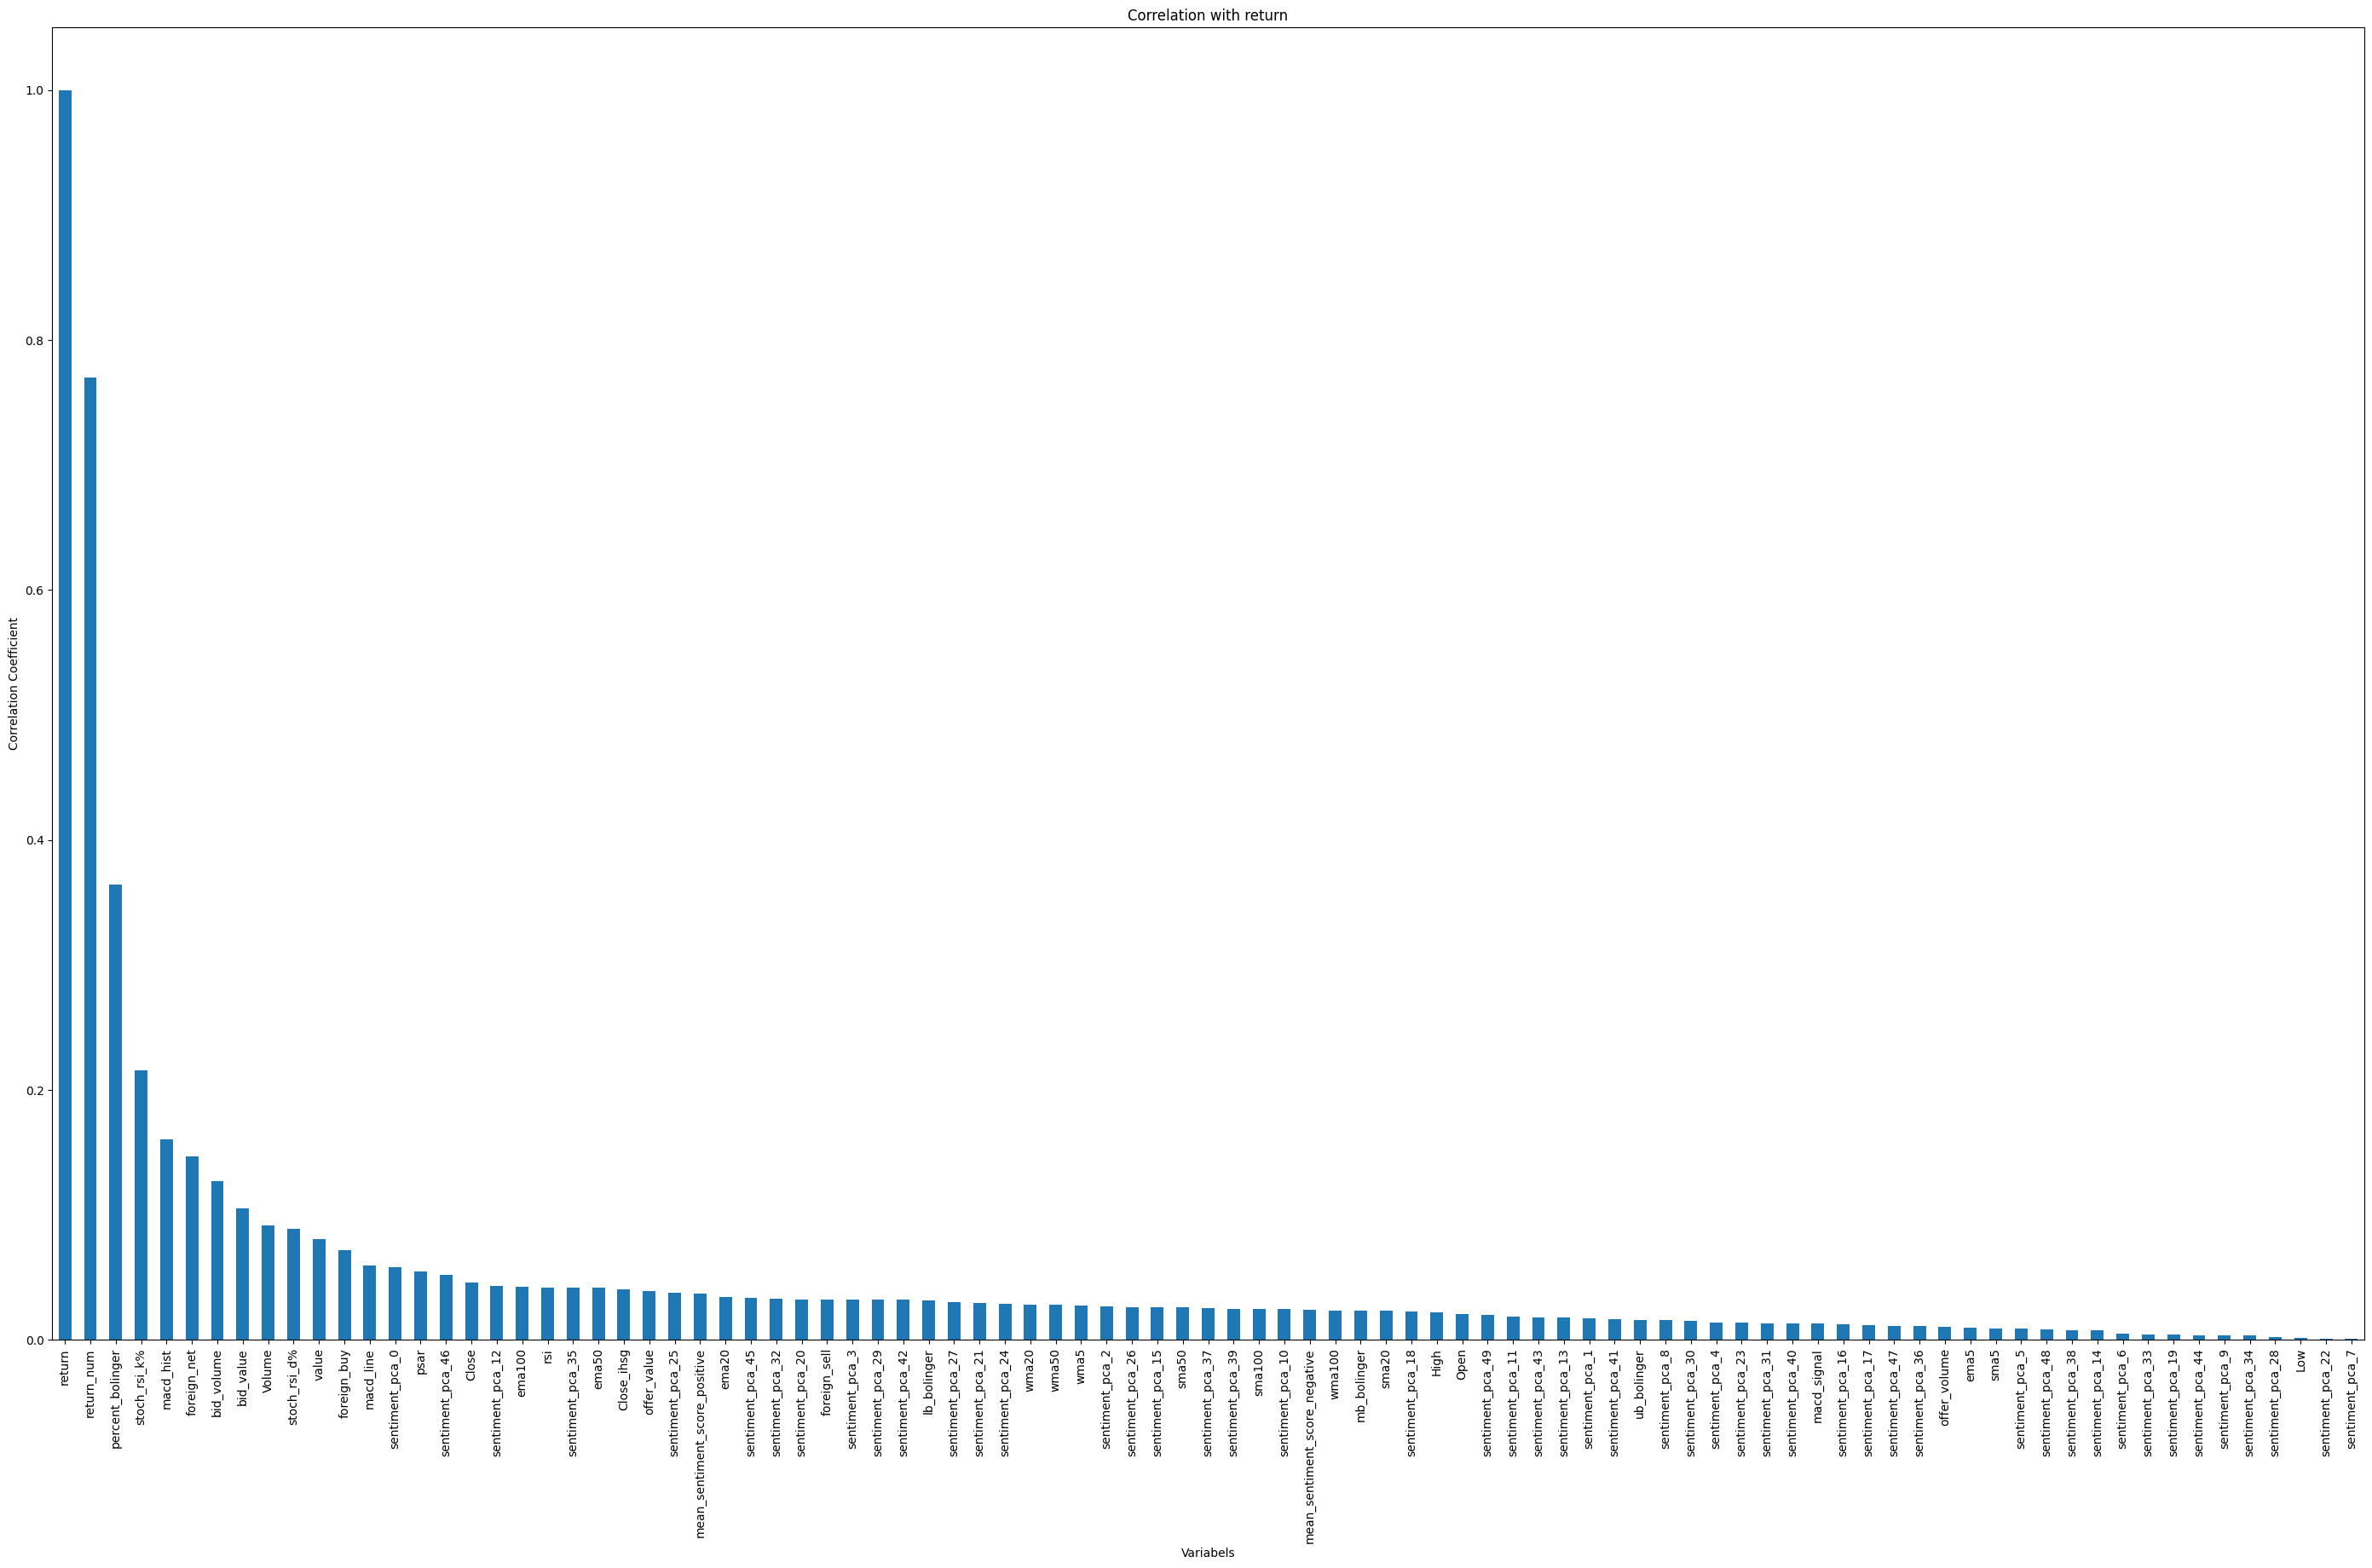

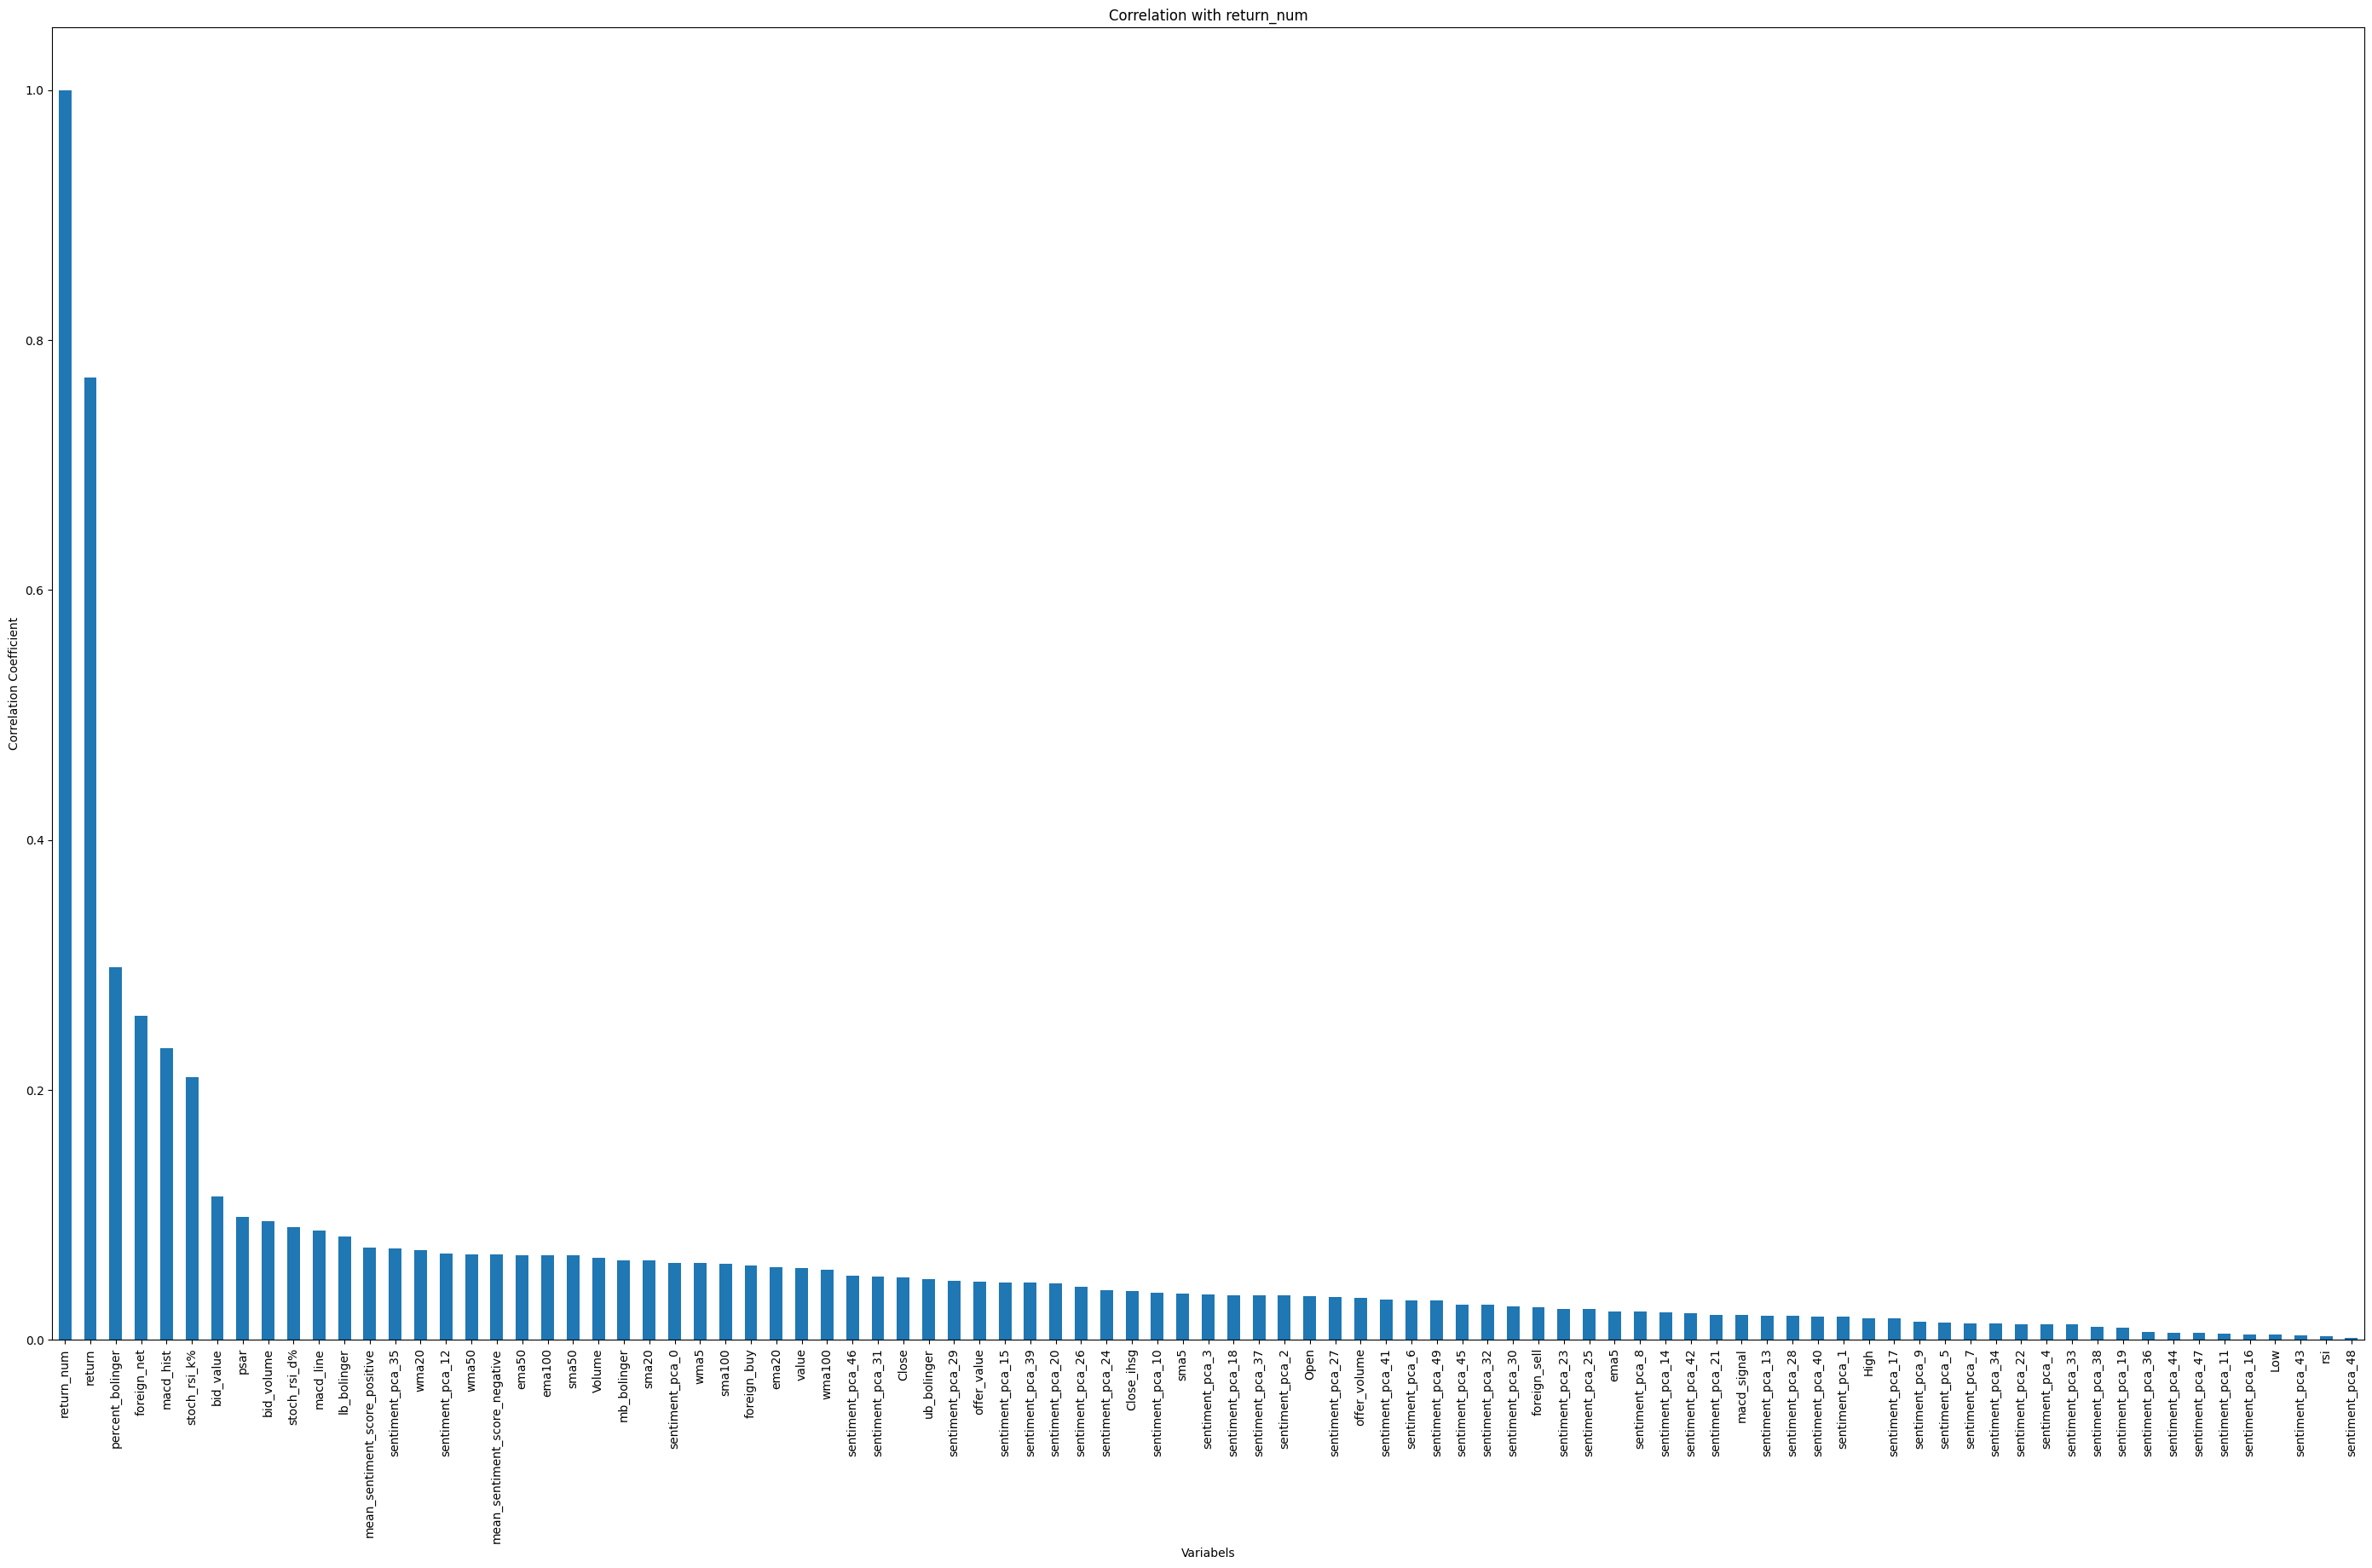

In [740]:
for i in ['return', 'return_num']:
    target_corr = df.select_dtypes(include=['number']).corr()[i]
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)

    plt.figure(figsize=(35, 20))
    target_corr_sorted.plot(kind='bar')
    plt.title(f'Correlation with {i}')
    plt.xlabel('Variabels')
    plt.ylabel('Correlation Coefficient')
plt.show()

## Feature Engineering

In [741]:
df.select_dtypes(include="number").columns

Index(['Close', 'Close_ihsg', 'High', 'Low', 'Open', 'Volume', 'bid_value',
       'bid_volume', 'ema100', 'ema20', 'ema5', 'ema50', 'foreign_buy',
       'foreign_sell', 'lb_bolinger', 'macd_hist', 'macd_line', 'macd_signal',
       'mb_bolinger', 'mean_sentiment_score_negative',
       'mean_sentiment_score_positive', 'offer_value', 'offer_volume',
       'percent_bolinger', 'psar', 'return', 'return_num', 'rsi',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_10',
       'sentiment_pca_11', 'sentiment_pca_12', 'sentiment_pca_13',
       'sentiment_pca_14', 'sentiment_pca_15', 'sentiment_pca_16',
       'sentiment_pca_17', 'sentiment_pca_18', 'sentiment_pca_19',
       'sentiment_pca_2', 'sentiment_pca_20', 'sentiment_pca_21',
       'sentiment_pca_22', 'sentiment_pca_23', 'sentiment_pca_24',
       'sentiment_pca_25', 'sentiment_pca_26', 'sentiment_pca_27',
       'sentiment_pca_28', 'sentiment_pca_29', 'sentiment_pca_3',
       'sentiment_pca_30', 'sentiment_pca_31', 's

In [742]:
features = df.columns.drop(['date', 'return', 'return_num', 'sentiment_score', *[f"sentiment_pca_{i}" for i in range(50)]])
df["return"]
X = df[features]

y = df['return_num']

In [743]:
X

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,66.000000,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,66.138614,66.666667,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,66.195275,66.888889,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,66.250814,67.089947,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,66.285451,67.176619,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,147.0,6037.841797,148.0,139.0,142.0,21.386982,147.0,18.090258,194.060024,146.732431,...,169.62,80.338110,77.213786,170.558606,26.351984,226.338416,140.252381,92.800000,178.606275,266024800.0
1572,149.0,6039.520996,155.0,146.0,148.0,21.963438,148.0,18.205629,193.167746,146.948390,...,167.80,54.644945,9.507265,168.805257,26.977335,225.675644,137.933333,93.200000,175.846275,-144472200.0
1573,148.0,6041.972168,152.0,147.0,150.0,20.994785,147.0,17.889761,192.273335,147.048543,...,166.16,37.309350,25.207001,167.518626,26.002531,224.836436,135.976190,95.533333,173.407059,-287818500.0
1574,149.0,6108.208984,152.0,147.0,148.0,21.166431,149.0,16.941977,191.416437,147.234396,...,164.54,11.571422,0.000000,165.823727,26.173223,223.502178,133.638095,97.000000,170.903529,-335497100.0


In [744]:
y

0       0.0
1       7.0
2      -4.0
3       0.0
4      -1.0
       ... 
1571    5.0
1572    2.0
1573   -1.0
1574    1.0
1575    1.0
Name: return_num, Length: 1576, dtype: float64

Hitung korelasi Pearson antara setiap fitur dan target. Pilih fitur yang nilai absolut korelasinya > 0.1.

- Mengapa threshold 0.3? Karena di bawah itu, hubungan linear sangat lemah fitur seperti Volume_Change biasanya di bawah 0.1 dan cenderung hanya menambah noise.

- Catatan: Korelasi linear tidak menangkap hubungan non-linear, tetapi untuk langkah awal penyaringan cukup baik. Model CNN-LSTM nanti bisa menangkap pola non-linear dari fitur yang tersisa.

# Data Splitting

In [745]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [746]:
X_train

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,66.000000,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,66.138614,66.666667,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,66.195275,66.888889,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,66.250814,67.089947,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,66.285451,67.176619,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,102.0,6598.211914,105.0,96.0,96.0,20.937452,101.0,17.802303,115.110085,101.971133,...,111.28,74.405938,68.359546,120.408834,25.558905,132.550891,93.409524,62.466667,111.310588,-129075300.0
1256,99.0,6545.850098,102.0,98.0,99.0,20.212538,98.0,18.344493,114.791074,101.688168,...,110.96,88.509269,97.168262,118.104437,24.812993,132.460792,93.933333,63.333333,111.164706,-97827400.0
1257,97.0,6665.044922,100.0,96.0,99.0,19.505707,96.0,17.727688,114.438775,101.241676,...,110.58,87.565356,97.168262,116.318361,24.090780,132.304950,94.185714,64.600000,110.967059,-4200.0
1258,94.0,6647.416992,98.0,94.0,97.0,19.722972,93.0,18.111639,114.034047,100.551993,...,110.14,98.112174,100.000000,114.947436,24.280510,132.022970,94.238095,65.133333,110.754510,10683500.0


In [747]:
X_test

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
1260,94.0,6471.946777,95.0,92.0,93.0,19.879317,93.0,17.379691,113.209655,99.191087,...,109.18,89.524101,68.572303,113.384469,24.420911,131.490693,93.461905,64.466667,110.197647,70064700.0
1261,86.0,6223.388184,95.0,70.0,95.0,21.068817,86.0,15.082233,112.670850,97.934793,...,108.44,86.082642,89.675623,113.312460,25.535297,131.062772,92.509524,63.200000,109.655686,138646400.0
1262,89.0,6311.660156,90.0,85.0,87.0,19.709496,88.0,18.287971,112.202121,97.083860,...,107.74,77.470614,74.163917,112.609697,24.189714,130.761584,91.157143,61.733333,109.045490,-42295200.0
1263,89.0,6381.673828,93.0,89.0,90.0,19.805340,88.0,16.584574,111.742673,96.313969,...,107.14,71.040592,49.282236,111.876232,24.311726,130.470297,89.880952,60.733333,108.603922,-4476300.0
1264,90.0,6258.179199,90.0,84.0,90.0,20.262043,88.0,4.615121,111.312125,95.712638,...,106.54,53.826765,38.034142,111.063226,24.728676,130.109901,88.595238,60.066667,108.099608,176446800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,147.0,6037.841797,148.0,139.0,142.0,21.386982,147.0,18.090258,194.060024,146.732431,...,169.62,80.338110,77.213786,170.558606,26.351984,226.338416,140.252381,92.800000,178.606275,266024800.0
1572,149.0,6039.520996,155.0,146.0,148.0,21.963438,148.0,18.205629,193.167746,146.948390,...,167.80,54.644945,9.507265,168.805257,26.977335,225.675644,137.933333,93.200000,175.846275,-144472200.0
1573,148.0,6041.972168,152.0,147.0,150.0,20.994785,147.0,17.889761,192.273335,147.048543,...,166.16,37.309350,25.207001,167.518626,26.002531,224.836436,135.976190,95.533333,173.407059,-287818500.0
1574,149.0,6108.208984,152.0,147.0,148.0,21.166431,149.0,16.941977,191.416437,147.234396,...,164.54,11.571422,0.000000,165.823727,26.173223,223.502178,133.638095,97.000000,170.903529,-335497100.0


# Data Training

In [748]:
X_train

,Close,Close_ihsg,High,Low,Open,Volume,bid_value,bid_volume,ema100,ema20,...,sma50,stoch_rsi_d%,stoch_rsi_k%,ub_bolinger,value,wma100,wma20,wma5,wma50,foreign_net
0,66.0,6283.581055,67.0,66.0,66.0,17.657965,66.0,16.559578,66.000000,66.000000,...,0.00,0.000000,0.000000,0.000000,21.855228,0.000000,0.000000,0.000000,0.000000,-7720600.0
1,73.0,6323.465820,74.0,66.0,66.0,20.185856,72.0,16.889777,66.138614,66.666667,...,0.00,0.000000,0.000000,0.000000,24.443373,0.000000,0.000000,0.000000,0.000000,11078200.0
2,69.0,6257.402832,73.0,68.0,73.0,19.777121,68.0,16.985091,66.195275,66.888889,...,0.00,0.000000,0.000000,0.000000,24.033697,0.000000,0.000000,0.000000,0.000000,-126054900.0
3,69.0,6279.346191,70.0,68.0,69.0,18.484374,68.0,17.254636,66.250814,67.089947,...,0.00,0.000000,0.000000,0.000000,22.716842,0.000000,0.000000,0.000000,0.000000,-15032900.0
4,68.0,6225.686035,69.0,66.0,69.0,18.974357,67.0,16.705588,66.285451,67.176619,...,0.00,0.000000,0.000000,0.000000,23.182099,0.000000,0.000000,46.000000,0.000000,-4583400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,102.0,6598.211914,105.0,96.0,96.0,20.937452,101.0,17.802303,115.110085,101.971133,...,111.28,74.405938,68.359546,120.408834,25.558905,132.550891,93.409524,62.466667,111.310588,-129075300.0
1256,99.0,6545.850098,102.0,98.0,99.0,20.212538,98.0,18.344493,114.791074,101.688168,...,110.96,88.509269,97.168262,118.104437,24.812993,132.460792,93.933333,63.333333,111.164706,-97827400.0
1257,97.0,6665.044922,100.0,96.0,99.0,19.505707,96.0,17.727688,114.438775,101.241676,...,110.58,87.565356,97.168262,116.318361,24.090780,132.304950,94.185714,64.600000,110.967059,-4200.0
1258,94.0,6647.416992,98.0,94.0,97.0,19.722972,93.0,18.111639,114.034047,100.551993,...,110.14,98.112174,100.000000,114.947436,24.280510,132.022970,94.238095,65.133333,110.754510,10683500.0


In [749]:
y_train

0       0.0
1       7.0
2      -4.0
3       0.0
4      -1.0
       ... 
1255    8.0
1256   -3.0
1257   -2.0
1258   -3.0
1259   -2.0
Name: return_num, Length: 1260, dtype: float64

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=3,
    random_state=0,
    n_jobs=1,
    max_features="log2",
    criterion="friedman_mse",
    min_samples_split=5,
    min_weight_fraction_leaf=0,
    min_impurity_decrease=0.9,
    oob_score=True,
    warm_start=True,
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'friedman_mse'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Data Predict

In [751]:
pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

result = pd.DataFrame({
    "actual": y_test,
    "prediction": pred
})

result.head(20)

MSE: 122.23070979964932
MAE: 6.804852522516651


,actual,prediction
1260,2.0,-0.232148
1261,-8.0,0.501744
1262,3.0,-0.402667
1263,0.0,-0.365719
1264,1.0,0.536781
1265,-6.0,-0.425248
1266,1.0,-0.290513
1267,5.0,-0.020607
1268,3.0,0.305951
1269,-13.0,-1.532006


In [752]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
23,percent_bolinger,0.126808
5,Volume,0.095028
38,foreign_net,0.076835
33,value,0.066021
31,stoch_rsi_k%,0.062952
12,foreign_buy,0.060426
6,bid_value,0.034332
7,bid_volume,0.032709
25,rsi,0.025370
21,offer_value,0.024480


# Data Evaluation

In [753]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE: ", rmse) 

RMSE:  11.055799826319637


# Trading Plan

In [754]:
signal = []

for p in pred:
    if p >= 0.01:
        signal.append("BUY")
    elif p <= -0.01:
        signal.append("SELL")
    else:
        signal.append("HOLD")

In [755]:
result = pd.DataFrame({
    "pred_return": pred,
    "signal": signal,
    "price": X_test['Close']
})

result

,pred_return,signal,price
1260,-0.232148,SELL,94.0
1261,0.501744,BUY,86.0
1262,-0.402667,SELL,89.0
1263,-0.365719,SELL,89.0
1264,0.536781,BUY,90.0
...,...,...,...
1571,1.600968,BUY,147.0
1572,1.519393,BUY,149.0
1573,-0.355364,SELL,148.0
1574,0.554044,BUY,149.0


# Strategy Simulation

In [756]:
data = result.copy()
strategy_return = []

for i in range(len(data)):
    actual_return = data["price"].shift(-1) / data["price"] - 1
    r = actual_return.iloc[i]
    s = data["signal"].iloc[i]

    if s == "BUY":
        strategy_return.append(r)
    elif s == "SELL":
        strategy_return.append(-r)
    else: 
        strategy_return.append(0)
    
data['strategy_return'] = strategy_return
data

,pred_return,signal,price,strategy_return
1260,-0.232148,SELL,94.0,0.085106
1261,0.501744,BUY,86.0,0.034884
1262,-0.402667,SELL,89.0,-0.000000
1263,-0.365719,SELL,89.0,-0.011236
1264,0.536781,BUY,90.0,-0.066667
...,...,...,...,...
1571,1.600968,BUY,147.0,0.013605
1572,1.519393,BUY,149.0,-0.006711
1573,-0.355364,SELL,148.0,-0.006757
1574,0.554044,BUY,149.0,0.006711


In [757]:
position = 0
entry_price = 0
equity = 100
equity_curve = []

for i in range(len(data)):
    price = data["price"].iloc[i]
    signal = data["signal"].iloc[i]

    if signal == "BUY" and position == 0:
        position = 1
        entry_price = price

    elif signal == "SELL" and position == 1:
        pnl = (price - entry_price) / entry_price
        equity *= (1 + pnl)
        position = 0
        entry_price = 0

    equity_curve.append(equity)

data["strategy_equity"] = equity_curve
data

,pred_return,signal,price,strategy_return,strategy_equity
1260,-0.232148,SELL,94.0,0.085106,100.000000
1261,0.501744,BUY,86.0,0.034884,100.000000
1262,-0.402667,SELL,89.0,-0.000000,103.488372
1263,-0.365719,SELL,89.0,-0.011236,103.488372
1264,0.536781,BUY,90.0,-0.066667,103.488372
...,...,...,...,...,...
1571,1.600968,BUY,147.0,0.013605,131.703430
1572,1.519393,BUY,149.0,-0.006711,131.703430
1573,-0.355364,SELL,148.0,-0.006757,138.241898
1574,0.554044,BUY,149.0,0.006711,138.241898


In [758]:
data["market_return"] = data["price"].pct_change().shift(-1)
data["market_equity"] = (1 + data["market_return"].fillna(0)).cumprod() * (100)
buy = data[data["signal"] == "BUY"]
sell = data[data["signal"] == "SELL"]

data.fillna(0, inplace=True)
data

,pred_return,signal,price,strategy_return,strategy_equity,market_return,market_equity
1260,-0.232148,SELL,94.0,0.085106,100.000000,-0.085106,91.489362
1261,0.501744,BUY,86.0,0.034884,100.000000,0.034884,94.680851
1262,-0.402667,SELL,89.0,-0.000000,103.488372,0.000000,94.680851
1263,-0.365719,SELL,89.0,-0.011236,103.488372,0.011236,95.744681
1264,0.536781,BUY,90.0,-0.066667,103.488372,-0.066667,89.361702
...,...,...,...,...,...,...,...
1571,1.600968,BUY,147.0,0.013605,131.703430,0.013605,158.510638
1572,1.519393,BUY,149.0,-0.006711,131.703430,-0.006711,157.446809
1573,-0.355364,SELL,148.0,-0.006757,138.241898,0.006757,158.510638
1574,0.554044,BUY,149.0,0.006711,138.241898,0.006711,159.574468


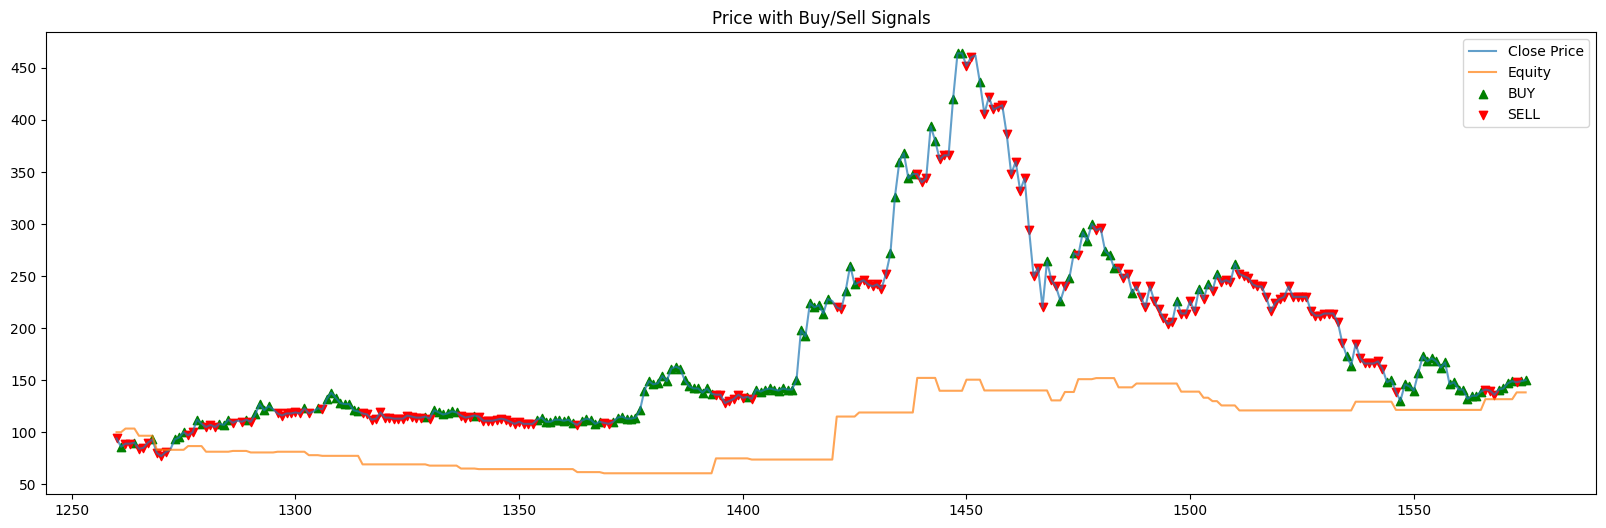

In [759]:
plt.figure(figsize=(20,6))

plt.plot(data["price"], label="Close Price", alpha=0.7)
plt.plot(data["strategy_equity"], label="Equity", alpha=0.7)

plt.scatter(buy.index, buy["price"], label="BUY", marker="^", color="green")
plt.scatter(sell.index, sell["price"], label="SELL", marker="v", color="red")

plt.title("Price with Buy/Sell Signals")
plt.legend()
plt.show()

In [760]:
data["strategy_pnl"] = data["strategy_return"]

print("Total return strategy:", data["strategy_equity"].iloc[-1])
print("Total return market:", data["market_equity"].iloc[-1])
print("Win rate BUY signal:", (data["strategy_return"] > 0).mean())

Total return strategy: 138.24189819494205
Total return market: 159.57446808510613
Win rate BUY signal: 0.38924050632911394


In [761]:
import joblib
from tensorflow.keras.models import save_model

# --- 1. Simpan Model LSTM ---
# Gunakan format .keras untuk menyimpan arsitektur, bobot, dan konfigurasi training.
model.save('model_saham_lstm.keras')
print("Model LSTM berhasil disimpan.")

# --- 2. Simpan Scaler dan Fitur Lainnya dengan Joblib ---
# Scaler untuk fitur input (X)
joblib.dump(scaler_X, 'scaler_X.joblib')
# Scaler untuk target (y)
joblib.dump(scaler_y, 'scaler_y.joblib')
# Daftar nama fitur yang terpilih
joblib.dump(selected_features, 'selected_features.joblib')

print("Scaler dan konfigurasi berhasil disimpan.")

AttributeError: 'RandomForestRegressor' object has no attribute 'save'